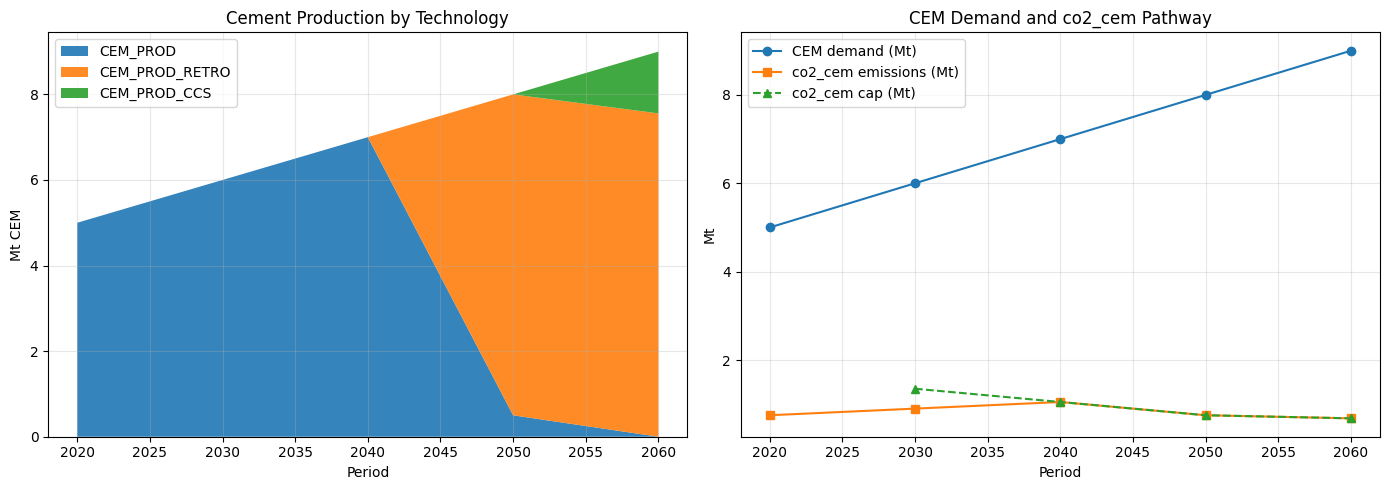

In [8]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = '/Users/jerrysong/Study_PKU/MFA_Workspace/ODYM_Application/summer-school/MFA-Temoa/data/2_temoa/22_mfa_utopia/222_mfa_utopia/mfa_utopia_cement.sqlite'
con = sqlite3.connect(DB_PATH)

q_tech = '''
SELECT period, tech, SUM(flow) AS cem_mt
FROM output_flow_out
WHERE scenario = 'MFA_Utopia_Temoa'
  AND output_comm = 'CEM'
  AND tech IN ('CEM_PROD', 'CEM_PROD_RETRO', 'CEM_PROD_CCS')
GROUP BY period, tech
ORDER BY period, tech
'''

df_tech = pd.read_sql_query(q_tech, con)
df_tech_pivot = df_tech.pivot(index='period', columns='tech', values='cem_mt').fillna(0.0)

q_co2 = '''
SELECT period, SUM(emission) AS co2_cem_mt
FROM output_emission
WHERE scenario = 'MFA_Utopia_Temoa'
  AND emis_comm = 'co2_cem'
GROUP BY period
ORDER BY period
'''

df_co2 = pd.read_sql_query(q_co2, con)

q_cap = '''
SELECT period, value AS co2_cem_cap_mt
FROM limit_emission
WHERE region = 'utopia'
  AND emis_comm = 'co2_cem'
  AND operator = 'le'
ORDER BY period
'''

df_cap = pd.read_sql_query(q_cap, con)

q_dem = '''
SELECT period, demand AS cem_demand_mt
FROM demand
WHERE region = 'utopia' AND commodity = 'CEM'
ORDER BY period
'''

df_dem = pd.read_sql_query(q_dem, con)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: technology production mix
if not df_tech_pivot.empty:
    cols = [c for c in ['CEM_PROD', 'CEM_PROD_RETRO', 'CEM_PROD_CCS'] if c in df_tech_pivot.columns]
    labels = {
        'CEM_PROD': 'CEM_PROD',
        'CEM_PROD_RETRO': 'CEM_PROD_RETRO',
        'CEM_PROD_CCS': 'CEM_PROD_CCS',
    }
    axes[0].stackplot(
        df_tech_pivot.index,
        [df_tech_pivot[c].values for c in cols],
        labels=[labels[c] for c in cols],
        alpha=0.9,
    )
axes[0].set_title('Cement Production by Technology')
axes[0].set_xlabel('Period')
axes[0].set_ylabel('Mt CEM')
axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.3)

# Right: demand + co2_cem + cap
axes[1].plot(df_dem['period'], df_dem['cem_demand_mt'], marker='o', label='CEM demand (Mt)')
axes[1].plot(df_co2['period'], df_co2['co2_cem_mt'], marker='s', label='co2_cem emissions (Mt)')
if not df_cap.empty:
    axes[1].plot(df_cap['period'], df_cap['co2_cem_cap_mt'], marker='^', linestyle='--', label='co2_cem cap (Mt)')
axes[1].set_title('CEM Demand and co2_cem Pathway')
axes[1].set_xlabel('Period')
axes[1].set_ylabel('Mt')
axes[1].legend(loc='upper left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [9]:
df_tech_pivot, df_co2, df_cap, df_dem

(tech    CEM_PROD  CEM_PROD_CCS  CEM_PROD_RETRO
 period                                        
 2020    5.000000      0.000000        0.000000
 2030    6.000000      0.000000        0.000000
 2040    7.000000      0.000000        0.000000
 2050    0.499996      0.000000        7.500004
 2060    0.000000      1.444447        7.555553,
    period  co2_cem_mt
 0    2020        0.75
 1    2030        0.90
 2    2040        1.05
 3    2050        0.75
 4    2060        0.68,
    period  co2_cem_cap_mt
 0    2030            1.35
 1    2040            1.05
 2    2050            0.75
 3    2060            0.68,
    period  cem_demand_mt
 0    2020            5.0
 1    2030            6.0
 2    2040            7.0
 3    2050            8.0
 4    2060            9.0)